<a href="https://colab.research.google.com/github/bswater/choko/blob/master/250501.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

In [100]:
import torch
from torch import nn, optim
from torchinfo import summary
from torchviz import make_dot
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [101]:
data_root = './data'

train_set0 = datasets.MNIST(
    data_root,
    True,
    download=True,
)

In [102]:
# len(train_set0)
image, label = train_set0[0]
print(type(image))
print(type(label))
print(np.array(image).shape)
print(np.array(label).dtype)
print()
print(np.array(image).max(), np.array(image).min())

<class 'PIL.Image.Image'>
<class 'int'>
(28, 28)
int64

255 0


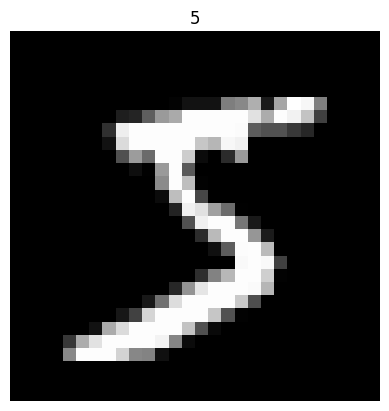

In [103]:
plt.imshow(image, cmap='gray')
plt.title(f'{label}')
plt.axis('off')
plt.show()

In [104]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 0 - 1, minmax normalization (transform) (정규화, 변환)
    transforms.Normalize(mean = 0.5, std = 0.5), # -1 ~ 1, z transform
    transforms.Lambda(lambda x:x.view(-1)) # 784
])

train_set = datasets.MNIST(
    data_root,
    True,
    transform,
    download=True
)

test_set = datasets.MNIST(
    data_root,
    False,
    transform,
    download=True
)

In [105]:
print(len(train_set))
print(len(test_set))

image, label = train_set[0]

print(type(image))
print(image.shape)
print(image.min(), image.max())

60000
10000
<class 'torch.Tensor'>
torch.Size([784])
tensor(-1.) tensor(1.)


In [106]:
## Mini-batch
batch_size = 500

train_loader = DataLoader(
    dataset = train_set,
    batch_size = batch_size,
    shuffle = True
)

test_loader = DataLoader(
    dataset = test_set,
    batch_size = batch_size,
    shuffle=False
)

In [107]:
for images, labels in train_loader:
  break

print(images.shape)
print(labels.shape)

torch.Size([500, 784])
torch.Size([500])


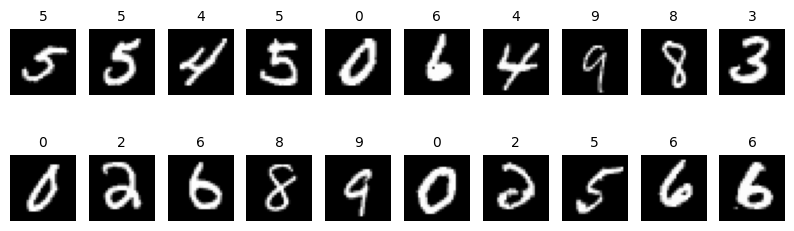

In [108]:
plt.figure(figsize = (10, 3))

for i in range(20):
  ax = plt.subplot(2, 10, i+1)

  image = images[i].detach().numpy()
  label = labels[i].item()

  plt.imshow(image.reshape(-1, 28), cmap='gray')
  ax.set_title(f'{label}', fontsize = 10)
  ax.axis('off')
plt.show()

In [109]:
## Model
class Net(nn.Module):
  def __init__(self, n_input, n_output, n_hidden):
    super().__init__()

    self.l1 = nn.Linear(n_input, n_hidden)
    self.l2 = nn.Linear(n_hidden, n_output)
    self.relu = nn.ReLU(inplace=True)

  def forward(self, x):
    x = self.l1(x)
    x = self.relu(x)
    x = self.l2(x)

    return x

In [110]:
n_input = image.shape[0] # 784
n_output = len(set(labels.numpy())) # 10
n_hidden = 128

net = Net(n_input, n_output, n_hidden)
net = net.to(device)

In [111]:
print(net)

Net(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU(inplace=True)
)


In [112]:
!pip install torchinfo
from torchinfo import summary
summary(net, (100, 784))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [100, 10]                 --
├─Linear: 1-1                            [100, 128]                100,480
├─ReLU: 1-2                              [100, 128]                --
├─Linear: 1-3                            [100, 10]                 1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 10.18
Input size (MB): 0.31
Forward/backward pass size (MB): 0.11
Params size (MB): 0.41
Estimated Total Size (MB): 0.83

In [113]:
##
lr = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = lr)

num_epochs = 10 ## 10*500(batch_size)
history = np.zeros((0, 5))

In [115]:
from tqdm import tqdm

In [90]:
for epoch in range(num_epochs):
  train_acc, train_loss = 0, 0
  test_acc, test_loss = 0, 0

  for inputs, labels in train_loader:
    inputs = inputs.to(device)  # cpu or gpu 든 작동하게 됨
    labels = labels.to(device)

    ## pred
    outputs = net(inputs)
    ## loss
    loss = criterion(outputs, labels)

    ## learning
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    predicted = outputs.argmax(-1)
    train_acc += (predicted == labels).float().mean().item()

  for inputs_test, labels_test in test_loader:
    inputs_test = inputs_test.to(device)
    labels_test = labels_test.to(device)

    ##pred
    outputs_test = net(inputs_test)
    ## loss
    loss_test = criterion(outputs_test, labels_test)

    test_loss += loss_test.item()
    predicted_test = outputs_test.argmax(-1)
    test_acc += (predicted_test == labels_test).float().mean().item()

  train_loss = train_loss / len(train_loader)
  train_acc = train_acc / len(train_loader)
  test_loss = test_loss / len(test_loader)
  test_acc = test_acc / len(test_loader)

  print(f'Epoch = {epoch}, Train loss = {train_loss:.4f}, Train acc = {train_acc:.4f}')
  print(f'Test loss = {test_loss:.4f}, Test acc = {test_acc:.4f}')
  print("="*50)
  result = np.array((epoch, train_loss, train_acc, test_loss, test_acc))
  history = np.vstack((history, result))



Epoch = 0, Train loss = 1.7986, Train acc = 0.5744
Test loss = 1.3049, Test acc = 0.7760
Epoch = 1, Train loss = 1.0230, Train acc = 0.8078
Test loss = 0.7842, Test acc = 0.8384
Epoch = 2, Train loss = 0.6985, Train acc = 0.8450
Test loss = 0.5929, Test acc = 0.8594
Epoch = 3, Train loss = 0.5675, Train acc = 0.8614
Test loss = 0.5045, Test acc = 0.8742
Epoch = 4, Train loss = 0.4992, Train acc = 0.8713
Test loss = 0.4551, Test acc = 0.8789
Epoch = 5, Train loss = 0.4574, Train acc = 0.8780
Test loss = 0.4200, Test acc = 0.8862
Epoch = 6, Train loss = 0.4288, Train acc = 0.8839
Test loss = 0.3978, Test acc = 0.8910
Epoch = 7, Train loss = 0.4080, Train acc = 0.8874
Test loss = 0.3798, Test acc = 0.8930
Epoch = 8, Train loss = 0.3920, Train acc = 0.8905
Test loss = 0.3665, Test acc = 0.8975
Epoch = 9, Train loss = 0.3790, Train acc = 0.8939
Test loss = 0.3547, Test acc = 0.9011


In [116]:
epoch
train_loss

0.3789755942920844

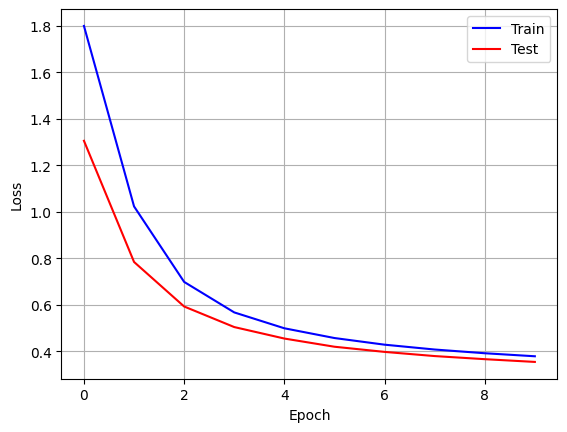

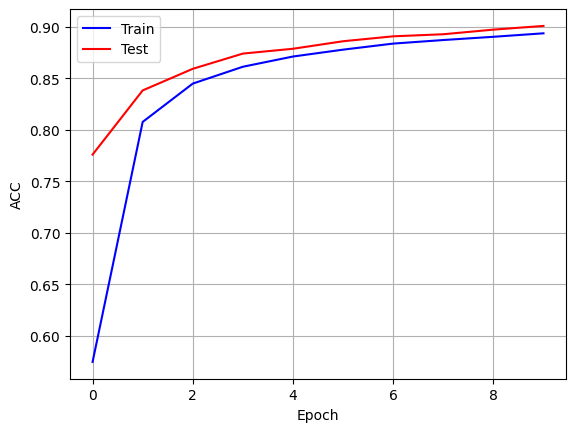

In [92]:
plt.plot(history[:, 0], history[:, 1], "b", label = 'Train')
plt.plot(history[:, 0], history[:, 3], "r", label = 'Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()
plt.show()
plt.plot(history[:, 0], history[:, 2], "b", label = 'Train')
plt.plot(history[:, 0], history[:, 4], "r", label = 'Test')
plt.xlabel('Epoch')
plt.ylabel('ACC')
plt.legend()
plt.grid()
plt.show()

In [117]:
for images, labels in test_loader:
  break

In [118]:
inputs = images.to(device)
labels = labels.to(device)

outputs = net(inputs)
predicted = torch.max(outputs, 1)[1]

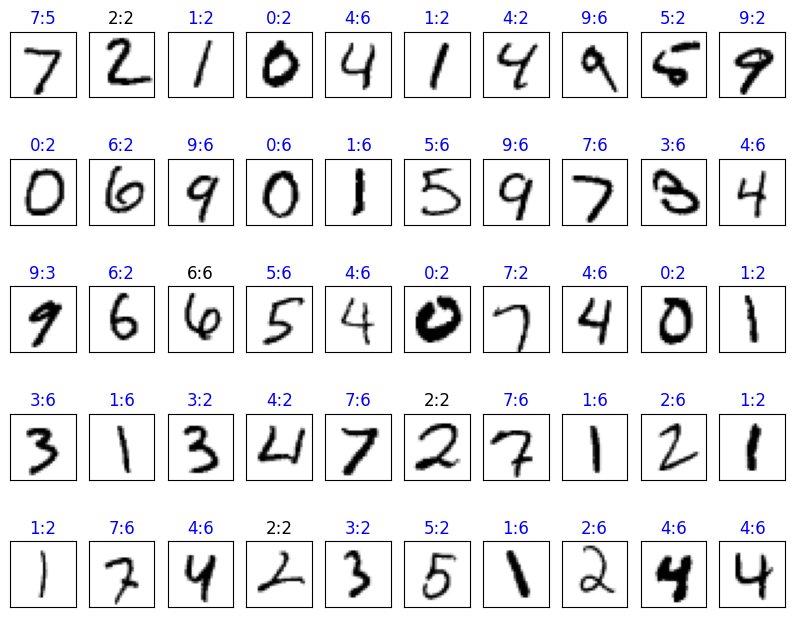

In [119]:
# 처음 50건의 이미지에 대해 "정답:예측"으로 출력

plt.figure(figsize=(10, 8))
for i in range(50):
  ax = plt.subplot(5, 10, i + 1)

  # 넘파이 배열로 변환
  image = images[i]
  label = labels[i]
  pred = predicted[i]
  if (pred == label):
    c = 'k'
  else:
    c = 'b'

  # 이미지의 범위를 [0, 1] 로 되돌림
  image2 = (image + 1)/ 2

  # 이미지 출력
  plt.imshow(image2.reshape(28, 28),cmap='gray_r')
  ax.set_title(f'{label}:{pred}', c=c)
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

In [120]:
class Net2(nn.Module):
  def __init__(self, n_input, n_output, n_hidden):
    super().__init__()

    self.l1 = nn.Linear(n_input, n_hidden)
    self.l2 = nn.Linear(n_hidden, n_hidden)
    self.l3 = nn.Linear(n_hidden, n_output) # hidden 이 많아지면 overfiting 가능성 증가
    self.relu = nn.ReLU(inplace=True)

  def forward(self, x):
    x = self.relu(self.l1(x))
    x = self.relu(self.l2(x))
    x = self.l3(x)

    return x

In [124]:
net = Net2(n_input, n_output, n_hidden).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = lr, momentum=0.9)

In [125]:
print(net) ## overfiting 막는 법, 데이터 증강, 레이아웃에 드랍아웃해주기?

Net2(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=128, bias=True)
  (l3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU(inplace=True)
)


In [128]:
##
for epoch in range(num_epochs):
  train_loss, train_acc = 0, 0
  test_loss, test_acc = 0, 0

  for inputs, labels in tqdm(train_loader):
    inputs = inputs.to(device)
    outputs = outputs.to(device)

    ## pred
    outputs = net(inputs)
    ## loss
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    predicted = outputs.argmax(-1)
    train_acc += (predicted == labels).float().mean().item()

  for inputs_test, labels_test in tqdm(test_loader):
    ## pred
    outputs_test = net(inputs_test)
    loss_test = criterion(outputs_test, labels_test)

    test_loss += loss_test.item()
    predicted_test = outputs_test.argmax(-1)
    test_acc += (predicted_test == labels_test).float().mean().item()

  train_loss = train_loss / len(train_loader)
  train_acc = train_acc / len(train_loader)
  test_loss = test_loss / len(test_loader)
  test_acc = test_acc / len(test_loader)

  print(f'Epoch = {epoch}, train loss = {train_loss:.4f}, train_acc = {train_acc:.4f}')
  print(f'test loss = {test_loss:.4f}, test_acc = {test_acc:.4f}')
  print("="*50)
  result = np.array([epoch, train_loss, train_acc, test_acc, test_loss])
  history = np.vstack((history, result))


  0%|          | 0/120 [00:00<?, ?it/s]


NameError: name 'net2' is not defined

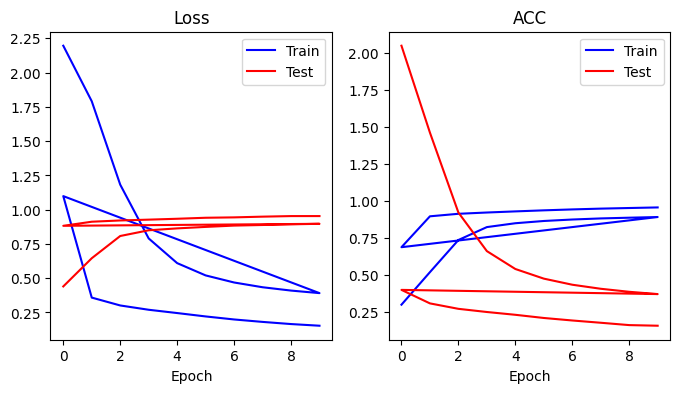

In [127]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].plot(history[:, 0], history[:, 1], 'b', label='Train')
axs[0].plot(history[:, 0], history[:, 3], 'r', label='Test')
axs[0].legend()
axs[0].set_title('Loss')
axs[0].set_xlabel('Epoch')

axs[1].plot(history[:, 0], history[:, 2], 'b', label='Train')
axs[1].plot(history[:, 0], history[:, 4], 'r', label='Test')
axs[1].legend()
axs[1].set_title('ACC')
axs[1].set_xlabel('Epoch')

plt.show()

In [129]:
## activation = Sigmoid
class Net3(nn.Module):
  def __init__(self, n_input, n_output, n_hidden):
    super().__init__()

    self.l1 = nn.Linear(n_input, n_hidden)
    self.l2 = nn.Linear(n_hidden, n_hidden)
    self.l3 = nn.Linear(n_hidden, n_output)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x=self.l1(x)
    x=self.sigmoid(x)
    x=self.l2(x)
    x=self.sigmoid(x)
    x=self.l3(x)

    return x

In [130]:
net = Net3(n_input, n_output, n_hidden).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = lr, momentum=0.9)

num_epochs = 10
history = np.zeros((0, 5))

In [131]:
##
for epoch in range(num_epochs):
  train_loss, train_acc = 0, 0
  test_loss, test_acc = 0, 0

  for inputs, labels in tqdm(train_loader):
    inputs = inputs.to(device)
    outputs = outputs.to(device)

    ## pred
    outputs = net(inputs)
    ## loss
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    predicted = outputs.argmax(-1)
    train_acc += (predicted == labels).float().mean().item()

  for inputs_test, labels_test in tqdm(test_loader):
    ## pred
    outputs_test = net(inputs_test)
    loss_test = criterion(outputs_test, labels_test)

    test_loss += loss_test.item()
    predicted_test = outputs_test.argmax(-1)
    test_acc += (predicted_test == labels_test).float().mean().item()

  train_loss = train_loss / len(train_loader)
  train_acc = train_acc / len(train_loader)
  test_loss = test_loss / len(test_loader)
  test_acc = test_acc / len(test_loader)

  print(f'Epoch = {epoch}, train loss = {train_loss:.4f}, train_acc = {train_acc:.4f}')
  print(f'test loss = {test_loss:.4f}, test_acc = {test_acc:.4f}')
  print("="*50)
  result = np.array([epoch, train_loss, train_acc, test_acc, test_loss])
  history = np.vstack((history, result))

100%|██████████| 20/20 [00:02<00:00,  8.42it/s]


Epoch = 0, train loss = 2.2960, train_acc = 0.1347
test loss = 2.2741, test_acc = 0.1151


100%|██████████| 20/20 [00:02<00:00,  7.67it/s]


Epoch = 1, train loss = 2.2394, train_acc = 0.2703
test loss = 2.1806, test_acc = 0.4418


100%|██████████| 20/20 [00:02<00:00,  8.53it/s]


...

Epoch = 7, train loss = 0.6047, train_acc = 0.8393
test loss = 0.5503, test_acc = 0.8556


100%|██████████| 20/20 [00:02<00:00,  8.56it/s]


Epoch = 8, train loss = 0.5337, train_acc = 0.8562
test loss = 0.4923, test_acc = 0.8662


100%|██████████| 20/20 [00:02<00:00,  8.51it/s]

Epoch = 9, train loss = 0.4861, train_acc = 0.8680
test loss = 0.4520, test_acc = 0.8770
